In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import neurite as ne

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


2025-11-19 18:20:22.661155: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-19 18:20:22.661297: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-19 18:20:22.700989: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda


In [2]:
subj1 = np.load('../Data/subj1.npz')
subj2 = np.load('../Data/subj2.npz')

volumes = np.stack([subj1['vol'], subj2['vol']]).astype('float32')
vol_shape = volumes.shape[1:]
print('Loaded volumes:', volumes.shape, 'vol_shape:', vol_shape)

x_tensor = torch.from_numpy(volumes).unsqueeze(1)

pair_indices = torch.tensor(
    [(i, j) for i in range(x_tensor.shape[0]) for j in range(x_tensor.shape[0]) if i != j],
    dtype=torch.long
)
print('Total ordered volume pairs:', pair_indices.shape[0])


Loaded volumes: (2, 160, 192, 224) vol_shape: (160, 192, 224)
Total ordered volume pairs: 2


In [3]:
ORIENTATIONS = ('axial', 'coronal', 'sagittal')
SLICE_BATCH_SIZE = 16  # per-orientation chunk size during fusion
SLICE_TRAIN_BATCH = 16  # batch of slices per Stage 1 step

train_slice_orientations = ORIENTATIONS


def sample_volume_pair(x_data, pair_indices, device=device):
    idx = torch.randint(0, pair_indices.shape[0], (1,)).item()
    moving = x_data[pair_indices[idx, 0]].unsqueeze(0).to(device)
    fixed = x_data[pair_indices[idx, 1]].unsqueeze(0).to(device)
    return moving, fixed


def volume_to_slices(volume, orientation):
    vol = volume[0, 0]
    if orientation == 'axial':
        data = vol
    elif orientation == 'coronal':
        data = vol.permute(1, 0, 2)
    elif orientation == 'sagittal':
        data = vol.permute(2, 0, 1)
    else:
        raise ValueError(f'Unknown orientation: {orientation}')
    return data.unsqueeze(1)


def slice_sampler(x_data, orientation):
    def pick_volume():
        vidx = torch.randint(0, x_data.shape[0], (1,)).item()
        return x_data[vidx:vidx+1]

    moving_vol = pick_volume()
    fixed_vol = pick_volume()
    moving_slices = volume_to_slices(moving_vol, orientation)
    fixed_slices = volume_to_slices(fixed_vol, orientation)
    depth = moving_slices.shape[0]
    slice_idx = torch.randint(0, depth, (1,)).item()
    moving_slice = moving_slices[slice_idx:slice_idx+1].to(device)
    fixed_slice = fixed_slices[slice_idx:slice_idx+1].to(device)
    return moving_slice, fixed_slice


def sample_slice_batch(x_data, orientation, batch_size=SLICE_TRAIN_BATCH, device=device):
    moving_batch = []
    fixed_batch = []
    for _ in range(batch_size):
        mv, fv = slice_sampler(x_data, orientation)
        moving_batch.append(mv)
        fixed_batch.append(fv)
    moving_batch = torch.cat(moving_batch, dim=0)
    fixed_batch = torch.cat(fixed_batch, dim=0)
    return moving_batch.to(device), fixed_batch.to(device)


def run_slice_batches(slice_model, moving_slices, fixed_slices, batch_size):
    outputs = []
    total = moving_slices.shape[0]
    for start in range(0, total, batch_size):
        end = min(start + batch_size, total)
        moving_chunk = moving_slices[start:end].to(device)
        fixed_chunk = fixed_slices[start:end].to(device)
        _, flow_chunk = slice_model(moving_chunk, fixed_chunk)
        outputs.append(flow_chunk.detach().cpu())
        del moving_chunk, fixed_chunk, flow_chunk
    torch.cuda.empty_cache()
    return torch.cat(outputs, dim=0)


def lift_flow(flow_slices, orientation, vol_shape):
    if orientation == 'axial':
        flow_x = flow_slices[:, 0][None, None, ...]
        flow_y = flow_slices[:, 1][None, None, ...]
        flow_z = torch.zeros_like(flow_x)
    elif orientation == 'coronal':
        flow_x = flow_slices[:, 0].permute(1, 0, 2)[None, None, ...]
        flow_z = flow_slices[:, 1].permute(1, 0, 2)[None, None, ...]
        flow_y = torch.zeros_like(flow_x)
    else:
        flow_y = flow_slices[:, 0].permute(1, 2, 0)[None, None, ...]
        flow_z = flow_slices[:, 1].permute(1, 2, 0)[None, None, ...]
        flow_x = torch.zeros_like(flow_y)
    flow_volume = torch.cat([flow_x, flow_y, flow_z], dim=1)
    contrib = torch.zeros_like(flow_volume)
    if orientation == 'axial':
        contrib[:, 0] += 1.0
        contrib[:, 1] += 1.0
    elif orientation == 'coronal':
        contrib[:, 0] += 1.0
        contrib[:, 2] += 1.0
    else:
        contrib[:, 1] += 1.0
        contrib[:, 2] += 1.0
    return flow_volume, contrib


def fuse_oriented_flows(flows, counts):
    aggregated = torch.stack(flows).sum(dim=0)
    total_counts = torch.stack(counts).sum(dim=0)
    return aggregated / total_counts.clamp(min=1.0)


In [4]:
class SpatialTransformer2D(nn.Module):
    def forward(self, src, flow):
        b, _, h, w = src.shape
        device = src.device
        yy, xx = torch.meshgrid(
            torch.arange(h, device=device),
            torch.arange(w, device=device),
            indexing='ij'
        )
        grid = torch.stack((xx, yy), dim=0).float()
        grid = grid.unsqueeze(0).repeat(b, 1, 1, 1)
        pts = grid + flow
        x = 2.0 * (pts[:, 0] / (w - 1.0)) - 1.0
        y = 2.0 * (pts[:, 1] / (h - 1.0)) - 1.0
        sample_grid = torch.stack((x, y), dim=-1)
        return F.grid_sample(src, sample_grid, mode='bilinear', padding_mode='border', align_corners=True)


class ConvBlock2D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.act(self.conv(x))


class SliceRegistrationNet(nn.Module):
    def __init__(self, enc_feats=(32, 64, 64), final_feats=(64, 32)):
        super().__init__()
        self.encoders = nn.ModuleList()
        in_channels = 2
        for nf in enc_feats:
            self.encoders.append(ConvBlock2D(in_channels, nf))
            in_channels = nf
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock2D(enc_feats[-1], enc_feats[-1])
        self.decoders = nn.ModuleList()
        decoder_in = enc_feats[-1]
        for skip_ch in reversed(enc_feats):
            self.decoders.append(ConvBlock2D(decoder_in + skip_ch, skip_ch))
            decoder_in = skip_ch
        self.final_conv0 = ConvBlock2D(decoder_in, final_feats[0])
        self.final_conv1 = ConvBlock2D(final_feats[0], final_feats[1])
        self.flow = nn.Conv2d(final_feats[1], 2, kernel_size=3, padding=1)
        self.transformer = SpatialTransformer2D()
        self.apply(self._init_weights)
        nn.init.zeros_(self.flow.weight)
        nn.init.zeros_(self.flow.bias)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, nonlinearity='leaky_relu')
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, src, tgt):
        x = torch.cat([src, tgt], dim=1)
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        for skip, dec in zip(reversed(skips), self.decoders):
            x = F.interpolate(x, scale_factor=2, mode='nearest')
            x = torch.cat([x, skip], dim=1)
            x = dec(x)
        x = self.final_conv0(x)
        x = self.final_conv1(x)
        flow = self.flow(x)
        moved = self.transformer(src, flow)
        return moved, flow


def flow_grad_l2_2d(flow):
    dx = flow[:, :, :, 1:] - flow[:, :, :, :-1]
    dy = flow[:, :, 1:, :] - flow[:, :, :-1, :]
    dx = F.pad(dx, (0, 1, 0, 0))
    dy = F.pad(dy, (0, 0, 0, 1))
    return dx.pow(2).mean() + dy.pow(2).mean()


class SpatialTransformer3D(nn.Module):
    def forward(self, src, flow):
        b, _, d, h, w = src.shape
        device = src.device
        zz, yy, xx = torch.meshgrid(
            torch.arange(d, device=device),
            torch.arange(h, device=device),
            torch.arange(w, device=device),
            indexing='ij'
        )
        grid = torch.stack((xx, yy, zz), dim=0).float()
        grid = grid.unsqueeze(0).repeat(b, 1, 1, 1, 1)
        pts = grid + flow
        x = 2.0 * (pts[:, 0] / (w - 1.0)) - 1.0
        y = 2.0 * (pts[:, 1] / (h - 1.0)) - 1.0
        z = 2.0 * (pts[:, 2] / (d - 1.0)) - 1.0
        sample_grid = torch.stack((x, y, z), dim=-1)
        return F.grid_sample(src, sample_grid, mode='bilinear', padding_mode='border', align_corners=True)


def flow_grad_l2_3d(flow):
    dx = flow[:, :, :, :, 1:] - flow[:, :, :, :, :-1]
    dy = flow[:, :, :, 1:, :] - flow[:, :, :, :-1, :]
    dz = flow[:, :, 1:, :, :] - flow[:, :, :-1, :, :]
    dx = F.pad(dx, (0, 1, 0, 0, 0, 0))
    dy = F.pad(dy, (0, 0, 0, 1, 0, 0))
    dz = F.pad(dz, (0, 0, 0, 0, 0, 1))
    return dx.pow(2).mean() + dy.pow(2).mean() + dz.pow(2).mean()


class FlowFusionNet(nn.Module):
    def __init__(self, in_channels=6, hidden_channels=32):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv3d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv3d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2)
        )
        self.block2 = nn.Sequential(
            nn.Conv3d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2)
        )
        self.out = nn.Conv3d(hidden_channels, 3, kernel_size=1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.out(x)


In [5]:
slice_model = SliceRegistrationNet().to(device)
slice_optimizer = torch.optim.Adam(slice_model.parameters(), lr=1e-4)
transformer2d = SpatialTransformer2D()


In [6]:
# Stage 1: train slice model
slice_epochs = 300
slice_steps_per_epoch = 96
slice_patience = 20
smooth_weight_2d = 0.005

slice_history = []
best_slice_loss = float('inf')
no_improve = 0

for epoch in range(slice_epochs):
    slice_model.train()
    running = 0.0
    for _ in range(slice_steps_per_epoch):
        orientation = train_slice_orientations[torch.randint(0, len(train_slice_orientations), (1,)).item()]
        moving_batch, fixed_batch = sample_slice_batch(x_tensor, orientation, batch_size=SLICE_TRAIN_BATCH, device=device)
        moved_slice, flow_slice = slice_model(moving_batch, fixed_batch)
        recon = F.mse_loss(moved_slice, fixed_batch)
        smooth = flow_grad_l2_2d(flow_slice)
        loss = recon + smooth_weight_2d * smooth
        slice_optimizer.zero_grad()
        loss.backward()
        slice_optimizer.step()
        running += loss.item()
    epoch_loss = running / slice_steps_per_epoch
    slice_history.append(epoch_loss)
    print(f"Slice Epoch {epoch+1}/{slice_epochs} loss: {epoch_loss:.6f}")
    if epoch_loss < best_slice_loss:
        best_slice_loss = epoch_loss
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= slice_patience:
            print(f"Slice training early stop at epoch {epoch+1}")
            break
slice_history = np.array(slice_history)


Slice Epoch 1/300 loss: 0.001291
Slice Epoch 2/300 loss: 0.000972
Slice Epoch 3/300 loss: 0.000798
Slice Epoch 4/300 loss: 0.000704
Slice Epoch 5/300 loss: 0.000611
Slice Epoch 6/300 loss: 0.000633
Slice Epoch 7/300 loss: 0.000623
Slice Epoch 8/300 loss: 0.000608
Slice Epoch 9/300 loss: 0.000597
Slice Epoch 10/300 loss: 0.000563
Slice Epoch 11/300 loss: 0.000562
Slice Epoch 12/300 loss: 0.000575
Slice Epoch 13/300 loss: 0.000583
Slice Epoch 14/300 loss: 0.000539
Slice Epoch 15/300 loss: 0.000563
Slice Epoch 16/300 loss: 0.000527
Slice Epoch 17/300 loss: 0.000570
Slice Epoch 18/300 loss: 0.000534
Slice Epoch 19/300 loss: 0.000501
Slice Epoch 20/300 loss: 0.000500
Slice Epoch 21/300 loss: 0.000528
Slice Epoch 22/300 loss: 0.000533
Slice Epoch 23/300 loss: 0.000512
Slice Epoch 24/300 loss: 0.000526
Slice Epoch 25/300 loss: 0.000527
Slice Epoch 26/300 loss: 0.000532
Slice Epoch 27/300 loss: 0.000506
Slice Epoch 28/300 loss: 0.000523
Slice Epoch 29/300 loss: 0.000500
Slice Epoch 30/300 loss

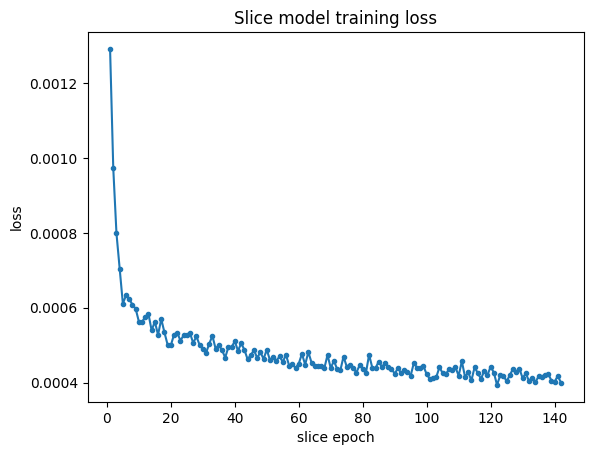

In [7]:
plt.figure()
plt.plot(np.arange(1, len(slice_history)+1), slice_history, '.-')
plt.xlabel('slice epoch')
plt.ylabel('loss')
plt.title('Slice model training loss')
plt.show()


In [8]:
slice_model.eval()
with torch.no_grad():
    orientation = 'axial'
    moving_slice, fixed_slice = slice_sampler(x_tensor, orientation)
    moved_slice, flow_slice = slice_model(moving_slice, fixed_slice)
print('slice output shapes:', moved_slice.shape, flow_slice.shape)


slice output shapes: torch.Size([1, 1, 192, 224]) torch.Size([1, 2, 192, 224])


In [9]:
for param in slice_model.parameters():
    param.requires_grad = False
slice_model.eval()

fusion_model = FlowFusionNet(in_channels=6, hidden_channels=32).to(device)
fusion_optimizer = torch.optim.Adam(fusion_model.parameters(), lr=2e-4)
transformer3d = SpatialTransformer3D().to(device)


In [10]:
torch.cuda.empty_cache()

fusion_epochs = 200
fusion_steps_per_epoch = 8
fusion_patience = 15
fusion_smooth_weight = 0.005

fusion_history = []
best_fusion_loss = float('inf')
no_improve = 0

for epoch in range(fusion_epochs):
    fusion_model.train()
    running = 0.0
    for _ in range(fusion_steps_per_epoch):
        moving, fixed = sample_volume_pair(x_tensor, pair_indices, device=device)
        flows = []
        counts = []
        for orientation in ORIENTATIONS:
            moving_slices = volume_to_slices(moving, orientation)
            fixed_slices = volume_to_slices(fixed, orientation)
            flow_slices = run_slice_batches(slice_model, moving_slices, fixed_slices, batch_size=SLICE_BATCH_SIZE)
            lifted_flow, lifted_count = lift_flow(flow_slices.to(device), orientation, vol_shape)
            flows.append(lifted_flow)
            counts.append(lifted_count)
        fused_flow = fuse_oriented_flows(flows, counts)
        fusion_input = torch.cat([flows[0][:, :2], flows[1][:, :2], flows[2][:, :2]], dim=1)
        fusion_flow = fusion_model(fusion_input)
        total_flow = fused_flow + fusion_flow
        moved = transformer3d(moving, total_flow)
        recon = F.mse_loss(moved, fixed)
        smooth = flow_grad_l2_3d(total_flow)
        loss = recon + fusion_smooth_weight * smooth
        fusion_optimizer.zero_grad()
        loss.backward()
        fusion_optimizer.step()
        running += loss.item()
    epoch_loss = running / fusion_steps_per_epoch
    fusion_history.append(epoch_loss)
    print(f"Fusion Epoch {epoch+1}/{fusion_epochs} loss: {epoch_loss:.6f}")
    if epoch_loss < best_fusion_loss:
        best_fusion_loss = epoch_loss
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= fusion_patience:
            print(f"Fusion training early stop at epoch {epoch+1}")
            break
fusion_history = np.array(fusion_history)


Fusion Epoch 1/200 loss: 0.001288
Fusion Epoch 2/200 loss: 0.001174
Fusion Epoch 3/200 loss: 0.001128
Fusion Epoch 4/200 loss: 0.001087
Fusion Epoch 5/200 loss: 0.001044
Fusion Epoch 6/200 loss: 0.000998
Fusion Epoch 7/200 loss: 0.000982
Fusion Epoch 8/200 loss: 0.000970
Fusion Epoch 9/200 loss: 0.000961
Fusion Epoch 10/200 loss: 0.000951
Fusion Epoch 11/200 loss: 0.000948
Fusion Epoch 12/200 loss: 0.000942
Fusion Epoch 13/200 loss: 0.000939
Fusion Epoch 14/200 loss: 0.000935
Fusion Epoch 15/200 loss: 0.000933
Fusion Epoch 16/200 loss: 0.000926
Fusion Epoch 17/200 loss: 0.000924
Fusion Epoch 18/200 loss: 0.000923
Fusion Epoch 19/200 loss: 0.000920
Fusion Epoch 20/200 loss: 0.000920
Fusion Epoch 21/200 loss: 0.000916
Fusion Epoch 22/200 loss: 0.000915
Fusion Epoch 23/200 loss: 0.000913
Fusion Epoch 24/200 loss: 0.000910
Fusion Epoch 25/200 loss: 0.000909
Fusion Epoch 26/200 loss: 0.000909
Fusion Epoch 27/200 loss: 0.000906
Fusion Epoch 28/200 loss: 0.000909
Fusion Epoch 29/200 loss: 0.0

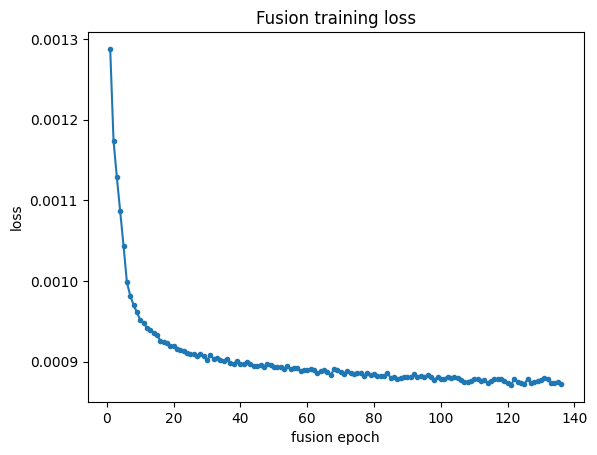

In [11]:
plt.figure()
plt.plot(np.arange(1, len(fusion_history)+1), fusion_history, '.-')
plt.xlabel('fusion epoch')
plt.ylabel('loss')
plt.title('Fusion training loss')
plt.show()


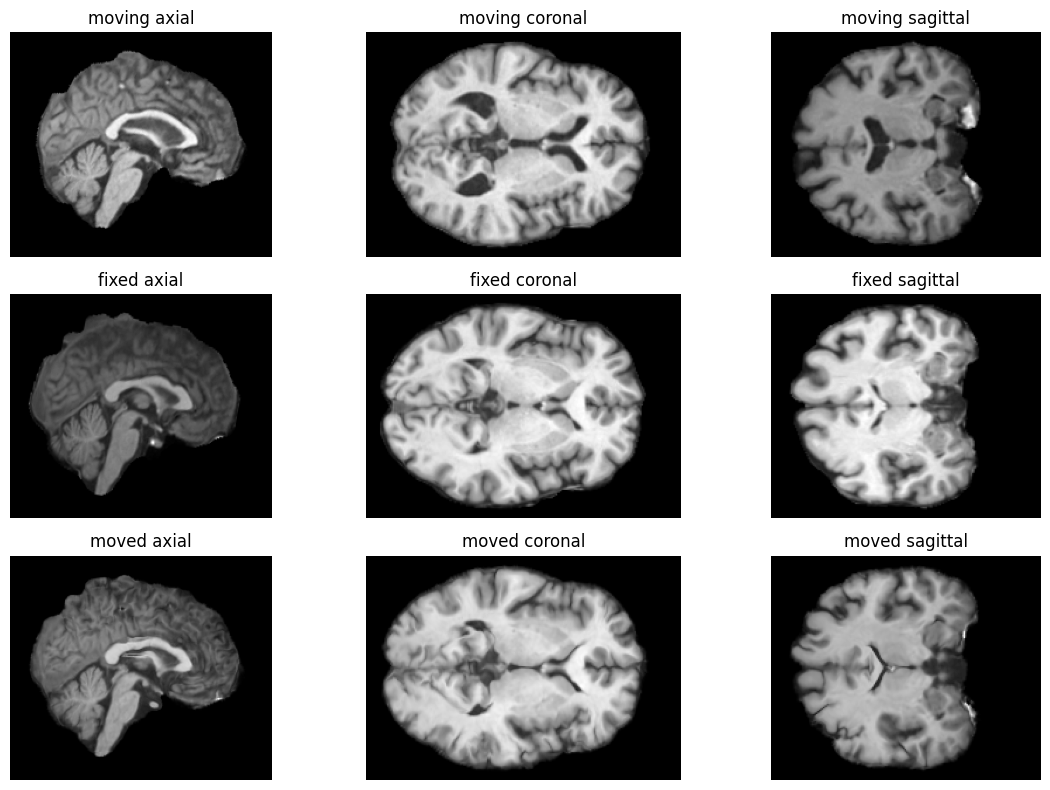

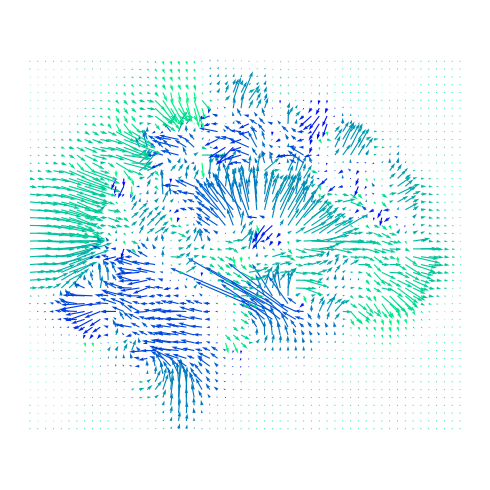

(<Figure size 500x500 with 1 Axes>, [<Axes: >])

In [12]:
slice_model.eval()
fusion_model.eval()
with torch.no_grad():
    moving, fixed = sample_volume_pair(x_tensor, pair_indices, device=device)
    flows = []
    counts = []
    for orientation in ORIENTATIONS:
        moving_slices = volume_to_slices(moving, orientation)
        fixed_slices = volume_to_slices(fixed, orientation)
        flow_slices = run_slice_batches(slice_model, moving_slices, fixed_slices, batch_size=4)
        lifted_flow, lifted_count = lift_flow(flow_slices.to(device), orientation, vol_shape)
        flows.append(lifted_flow)
        counts.append(lifted_count)
    fused_flow = fuse_oriented_flows(flows, counts)
    fusion_input = torch.cat([flows[0][:, :2], flows[1][:, :2], flows[2][:, :2]], dim=1)
    fusion_flow = fusion_model(fusion_input)
    total_flow = fused_flow + fusion_flow
    moved, flow = transformer3d(moving, total_flow), total_flow

moving_np = moving[0, 0].cpu().numpy()
fixed_np = fixed[0, 0].cpu().numpy()
moved_np = moved[0, 0].cpu().numpy()
flow_np = flow[0].permute(1, 2, 3, 0).cpu().numpy()

# slice visualizations

def mid_slices(volume):
    axial = volume[volume.shape[0] // 2]
    coronal = volume[:, volume.shape[1] // 2, :]
    sagittal = volume[:, :, volume.shape[2] // 2]
    return [axial, coronal, sagittal]

vols = mid_slices(moving_np) + mid_slices(fixed_np) + mid_slices(moved_np)
titles = ['moving axial', 'moving coronal', 'moving sagittal',
          'fixed axial', 'fixed coronal', 'fixed sagittal',
          'moved axial', 'moved coronal', 'moved sagittal']
plt.figure(figsize=(12, 8))
for idx, (img, title) in enumerate(zip(vols, titles), 1):
    plt.subplot(3, 3, idx)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()

# axial flow visualization like 3D notebook
mid_z = flow_np.shape[0] // 2
axial_flow = flow_np[mid_z, :, :, :2]
step = 4
ne.plot.flow([axial_flow[::step, ::step, :]], width=5)


In [13]:
import os
save_dir = '../trained_weights'
os.makedirs(save_dir, exist_ok=True)
split_slice_path = os.path.join(save_dir, '2p5_split_slice.pth')
split_fusion_path = os.path.join(save_dir, '2p5_split_fusion.pth')
torch.save(slice_model.state_dict(), split_slice_path)
torch.save(fusion_model.state_dict(), split_fusion_path)
print('Saved split slice model to', split_slice_path)
print('Saved fusion model to', split_fusion_path)


Saved split slice model to ../trained_weights/2p5_split_slice.pth
Saved fusion model to ../trained_weights/2p5_split_fusion.pth
